# 결정 트리

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [10]:
# (생략된 단계) 문제 정의 => 목표 명확히, 문제를 찾는 것.
# 알콜, 설탕, ph 농도로 레드와인 화이트와인을 분류하는 것.

# 데이터 수집
wine = pd.read_csv(r'data\red-wine-quality.csv')


In [ ]:
# x (data, feature) 와 y(target, label)로 나누는 과정
data   = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()           # 0=red, 1=white

In [9]:
# 데이터 나누기
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state= 42
)

# 표준화 스케일링
ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled = ss.transform(test_input)

In [11]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [12]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [15]:
lr = LogisticRegression() # 모델
lr.fit(train_scaled, train_target) # 학습
print(lr.score(test_scaled, test_target)) # 평가 (테스트 데이터셋)
print(lr.score(train_scaled, train_target)) # 평가 (훈련 데이터셋)

0.7776923076923077
0.7808350971714451


- 로지스틱 회귀로는 복잡한 비선형적 패턴을 가진 분류 문제를 해결하기 어렵다.
- 선으로 긋는 결정 경계로 나누는 것보다
- 단계별로 구분선을 쌓아서 가는 방식의 분류가 필요할 수 있다 => 결정 트리

# 결정 트리

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
# 데이터는 와인 데이터 그대로 사용
dt = DecisionTreeClassifier()
dt.fit(train_input, train_target) # 결정트리에서는 스케일링 된 데이터가 필요 없음.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [19]:
print("훈련 데이터 : ", dt.score(train_input, train_target))
print("학습 데이터 : ", dt.score(test_input, test_target))


훈련 데이터 :  0.996921300750433
학습 데이터 :  0.8561538461538462


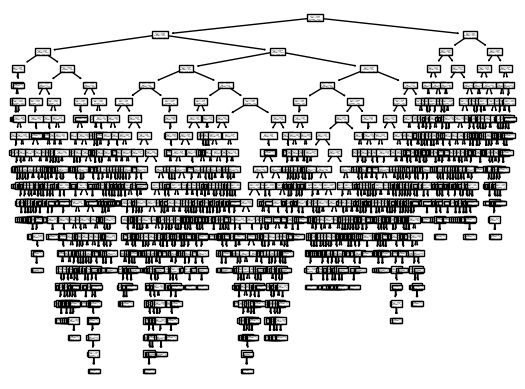

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.Figure(figsize=(10, 7))
plot_tree(dt)
plt.show()

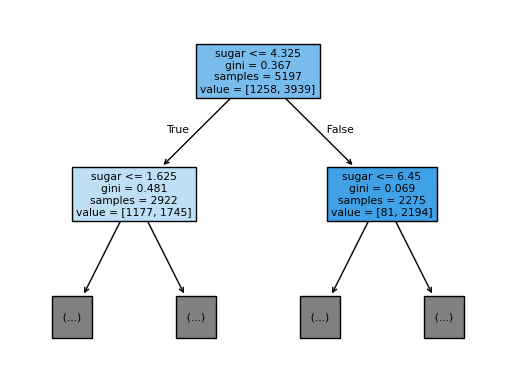

In [22]:
plt.Figure(figsize=(10, 7))
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'ph'])
plt.show()


## 가지치기 (Pruning)

In [23]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(train_input, train_target)
print("훈련 데이터 : ", dt.score(train_input, train_target))
print("학습 데이터 : ", dt.score(test_input, test_target))


훈련 데이터 :  0.8454877814123533
학습 데이터 :  0.8415384615384616


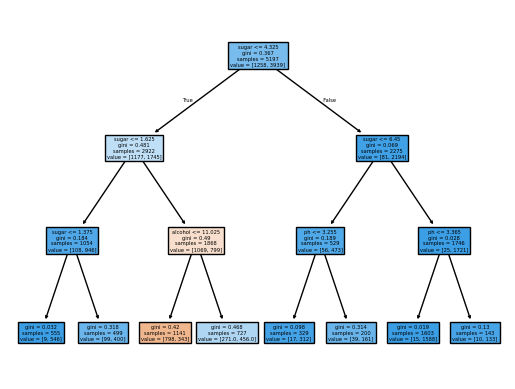

In [25]:
plt.Figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'ph'])
plt.show()

In [28]:
# 특성별 중요도
# [알콜 : 12% , sugar : 87% , pH : 0.8%]
dt.feature_importances_

array([0.12345626, 0.86862934, 0.0079144 ])

In [34]:
# 가지치기 최적 depth를 찾아보기 실험
for depth in [1,2,3,4,5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(train_input, train_target)
    tr = dt.score(train_input, train_target)
    te = dt.score(test_input, test_target)
    print(f"max_depth={depth} : train = {tr:.4f}, test={te:.4f}")


max_depth=1 : train = 0.7579, test=0.7377
max_depth=2 : train = 0.8099, test=0.7962
max_depth=3 : train = 0.8455, test=0.8415
max_depth=4 : train = 0.8572, test=0.8485
max_depth=5 : train = 0.8672, test=0.8608
max_depth=None : train = 0.9969, test=0.8585


## 앙상블
### 랜덤 포레스트

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

rf = RandomForestClassifier()
rf.fit(train_input, train_target)
scores = cross_validate(rf, train_input, train_target)
scores # 학습 시간, 평가 시간, 성능
print(scores['test_score']) # 정확도
scores['test_score'].mean()

[0.88557692 0.87980769 0.90760346 0.89220404 0.88546679]


np.float64(0.8901317835196565)

### Gradient Boosting

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
scores = cross_validate(gb, train_input, train_target, return_train_score = True)

In [44]:
print(scores['train_score'])
print(scores['test_score'])


[0.89006495 0.88958383 0.88239538 0.89249639 0.88600289]
[0.86634615 0.87019231 0.89412897 0.85948027 0.86910491]


In [48]:
from sklearn.ensemble import HistGradientBoostingClassifier
gb = HistGradientBoostingClassifier(random_state= 42)
scores = cross_validate(gb, train_input, train_target, return_train_score = True)
print(scores['train_score'])
print(scores['test_score'])


[0.93192206 0.93216262 0.92857143 0.93265993 0.93554594]
[0.87115385 0.88365385 0.90279115 0.86621752 0.87680462]


In [51]:
#히스토그램 기반 그레디언트 부스팅
# uv pip install xgboost

from xgboost import XGBClassifier

gb = XGBClassifier(random_stage =42)

scores = cross_validate(gb, train_input, train_target, return_train_score=True)

print(scores['train_score'].mean)
print(scores['test_score'].mean)

<built-in method mean of numpy.ndarray object at 0x0000018138B2BD50>
<built-in method mean of numpy.ndarray object at 0x0000018138B2B4B0>


In [53]:
!uv pip install lightgbm
from lightgbm import LGBMClassifier


gb = LGBMClassifier(random_stage =42)

scores = cross_validate(gb, train_input, train_target, return_train_score=True)

print(scores['train_score'].mean)
print(scores['test_score'].mean)

Checked 1 package in 6ms
c:\Users\student\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\student\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\student\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\student\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\student\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\sklea

<built-in method mean of numpy.ndarray object at 0x0000018138BEC090>
<built-in method mean of numpy.ndarray object at 0x000001816730B210>


c:\Users\student\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\student\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 그리드 서치

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'min_impurity_decrease':
        [0.0001, 0.0002, 0.0003, 0.0004, 0.0005],
    'max_depth': [3,4,5,6,7,8,9,10,11,12,13,14],
    'min_samples_split': [2,3,4,5,6,7,8,9,10,11,12],
}
# 5 × 12 × 11 = 660 조합 × 5폴드 = 3,300번!

gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
                  params, cv=5, n_jobs=-1)
gs.fit(train_input, train_target)
print(gs.best_params_)   # max_depth:14, ...
print(gs.best_score_)    # 0.8690